In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
trades = pd.read_csv("../data/historical_data.csv")
sentiment = pd.read_csv("../data/fear_greed_index.csv")

In [4]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [6]:
print("Trades Dataset Shape:",trades.shape)
print("Sentiment Dataset Shape:",sentiment.shape)

Trades Dataset Shape: (53319, 16)
Sentiment Dataset Shape: (2644, 4)


In [7]:
print(trades.columns)
print(sentiment.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')
Index(['timestamp', 'value', 'classification', 'date'], dtype='str')


In [8]:
trades.info()
sentiment.info()

<class 'pandas.DataFrame'>
RangeIndex: 53319 entries, 0 to 53318
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Account           53319 non-null  str    
 1   Coin              53319 non-null  str    
 2   Execution Price   53319 non-null  float64
 3   Size Tokens       53319 non-null  float64
 4   Size USD          53319 non-null  float64
 5   Side              53319 non-null  str    
 6   Timestamp IST     53319 non-null  str    
 7   Start Position    53319 non-null  float64
 8   Direction         53319 non-null  str    
 9   Closed PnL        53319 non-null  float64
 10  Transaction Hash  53319 non-null  str    
 11  Order ID          53319 non-null  int64  
 12  Crossed           53319 non-null  bool   
 13  Fee               53319 non-null  float64
 14  Trade ID          53319 non-null  float64
 15  Timestamp         53319 non-null  float64
dtypes: bool(1), float64(8), int64(1), str(6)
memory usa

In [9]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [10]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [11]:
trades.duplicated().sum()

np.int64(0)

In [12]:
sentiment.duplicated().sum()

np.int64(0)

In [14]:
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

In [15]:
trades["Timestamp IST"].head()

0   2024-12-02 22:50:00
1   2024-12-02 22:50:00
2   2024-12-02 22:50:00
3   2024-12-02 22:50:00
4   2024-12-02 22:50:00
Name: Timestamp IST, dtype: datetime64[us]

In [16]:
sentiment["date"] = pd.to_datetime(sentiment["date"])
sentiment["date"].head()

0   2018-02-01
1   2018-02-02
2   2018-02-03
3   2018-02-04
4   2018-02-05
Name: date, dtype: datetime64[us]

In [17]:
trades["date"] = trades["Timestamp IST"].dt.normalize()

In [18]:
trades[["Timestamp IST","date"]].head()

,Timestamp IST,date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [19]:
merged = pd.merge(
    trades,
    sentiment,
    on="date",
    how="left"
)
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


In [20]:
print("Total Trades:",merged.shape[0])

Total Trades: 53319


In [22]:
print(merged.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'date', 'timestamp', 'value', 'classification']


In [23]:
print("Unique Traders",
      merged["Account"].nunique())

Unique Traders 10


In [24]:
merged["Coin"].value_counts()

Coin
BTC     16746
HYPE     7881
ETH      6633
@107     3215
SOL      2930
        ...  
@34         1
@36         1
@37         1
@47         1
@53         1
Name: count, Length: 179, dtype: int64

In [25]:
merged["Side"].value_counts()

Side
SELL    26964
BUY     26355
Name: count, dtype: int64

In [26]:
merged["Closed PnL"].describe()

count     53319.000000
mean        118.570572
std        1560.428717
min     -117990.104100
25%           0.000000
50%           0.000000
75%          17.995800
max      135329.090100
Name: Closed PnL, dtype: float64

In [27]:
merged.groupby("classification")["Closed PnL"].mean().sort_values(ascending=False)

classification
Extreme Greed    160.154764
Extreme Fear     155.533552
Fear             131.032895
Neutral           92.919288
Greed             91.913789
Name: Closed PnL, dtype: float64

In [28]:
merged["classification"].value_counts()

classification
Greed            16373
Fear             14211
Neutral          10659
Extreme Greed     9708
Extreme Fear      2362
Name: count, dtype: int64

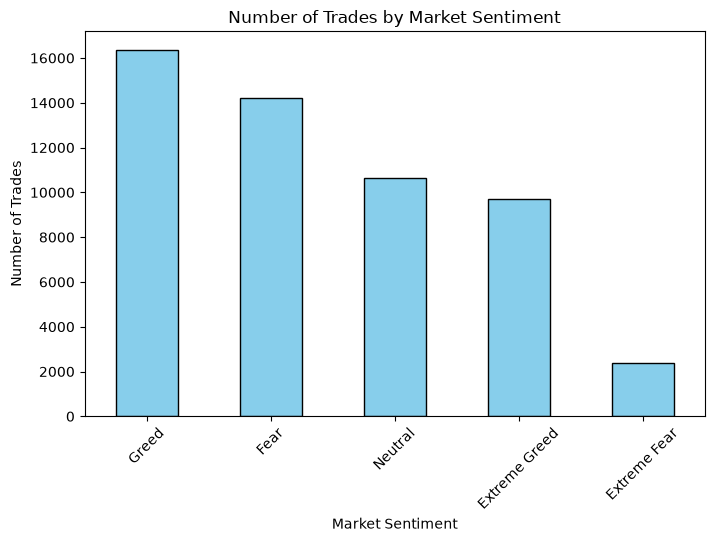

In [29]:
plt.figure(figsize=(8,5))

merged["classification"].value_counts().plot(
    kind="bar", 
    color="skyblue",
    edgecolor="black"
) 

plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)

plt.show()

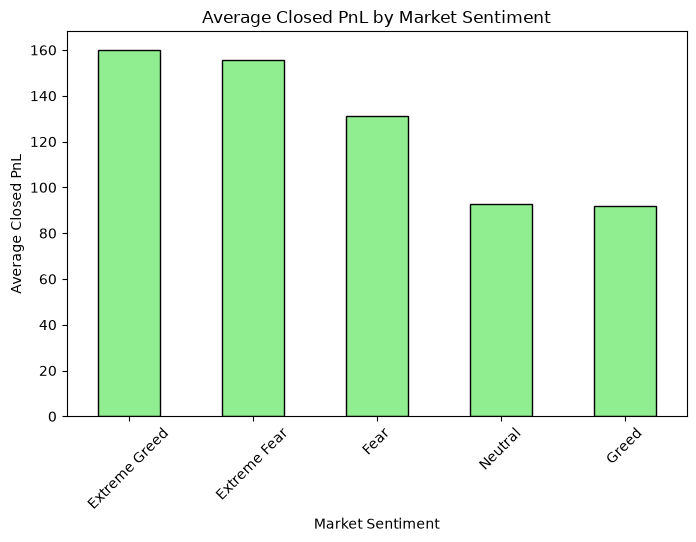

In [30]:
plt.figure(figsize=(8,5))

merged.groupby("classification")["Closed PnL"].mean().sort_values(ascending=False).plot(
    kind="bar",
    color="lightgreen",
    edgecolor="black"
)

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=45)

plt.show()

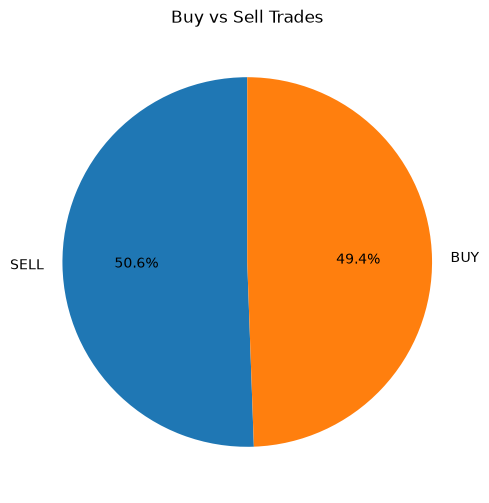

In [31]:
plt.figure(figsize=(6,6))

merged["Side"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Buy vs Sell Trades")
plt.ylabel("") 
 
plt.show()

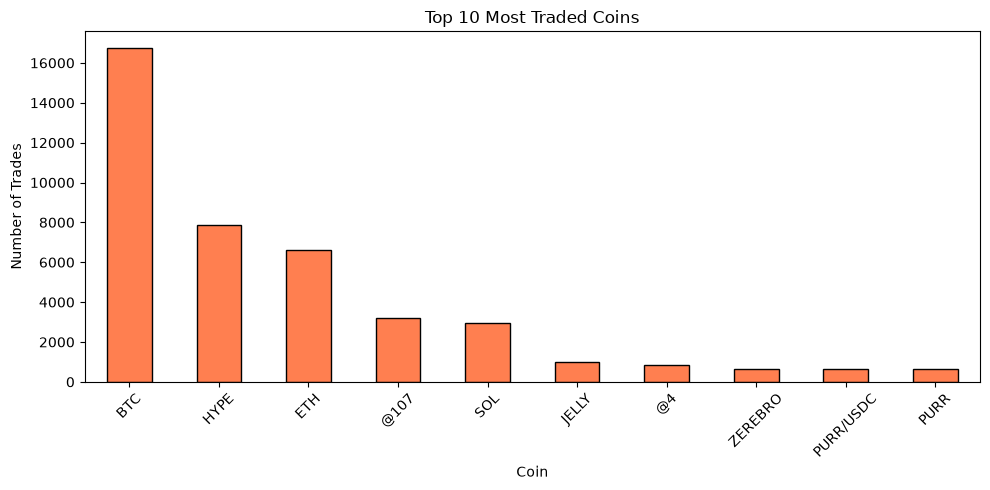

In [33]:
top10 = merged["Coin"].value_counts().head(10)

plt.figure(figsize=(10,5))
top10.plot(
    kind="bar",
    color="coral",
    edgecolor="black"
)

plt.title("Top 10 Most Traded Coins")
plt.xlabel("Coin")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

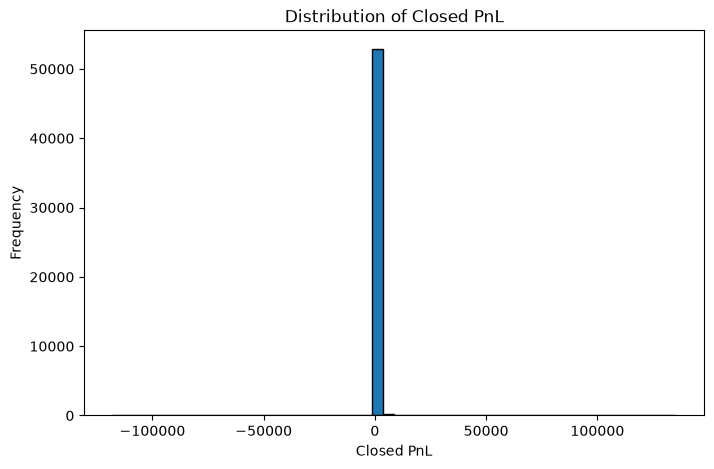

In [34]:
plt.figure(figsize=(8,5))

plt.hist(merged["Closed PnL"], bins=50, edgecolor="black")

plt.title("Distribution of Closed PnL")
plt.xlabel("Closed PnL")
plt.ylabel("Frequency")

plt.show()

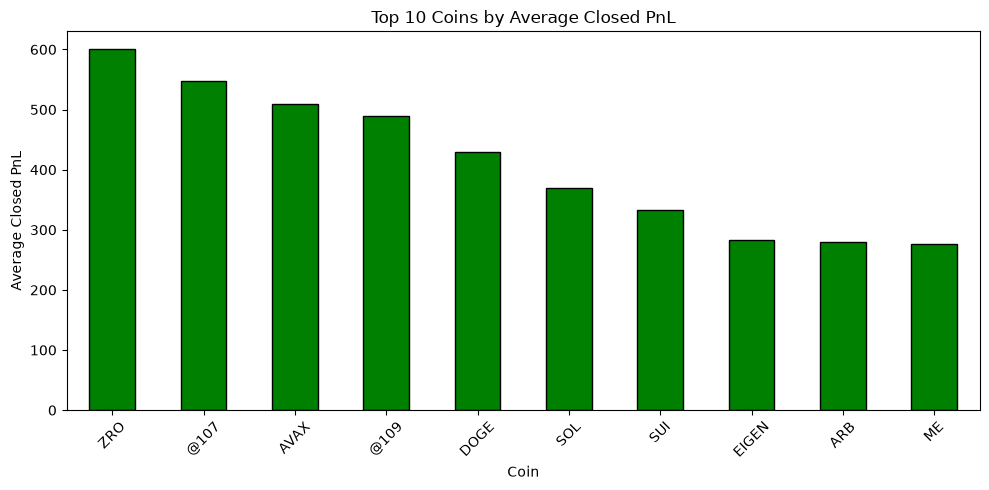

In [35]:
top_profit = (
    merged.groupby("Coin")["Closed PnL"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

top_profit.plot(
    kind="bar",     
    color="green",
    edgecolor="black"
)

plt.title("Top 10 Coins by Average Closed PnL")
plt.xlabel("Coin")
plt.ylabel("Average Closed PnL")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

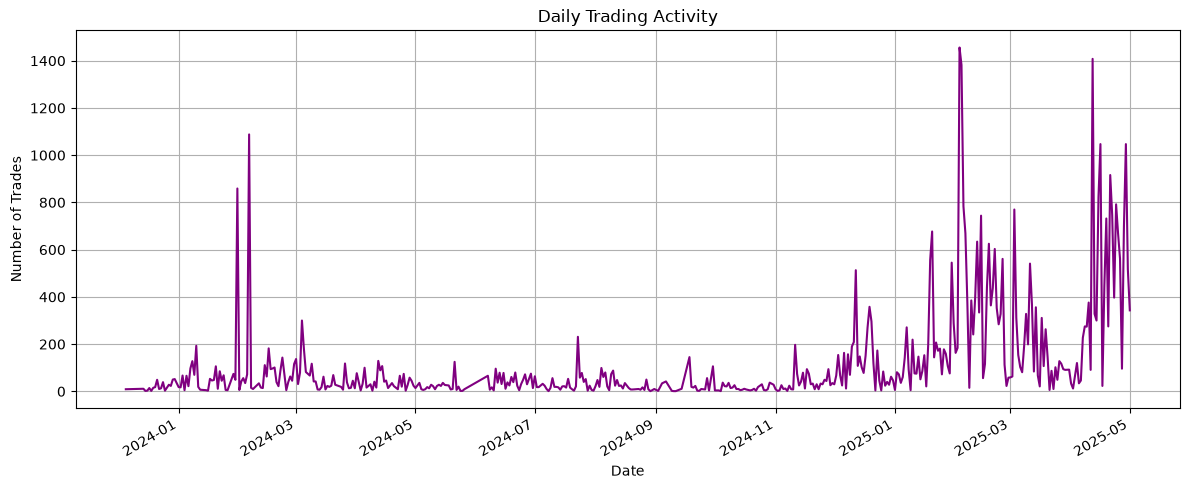

In [36]:
daily_trades = merged.groupby("date").size()

plt.figure(figsize=(12,5))

daily_trades.plot(
    color="purple",
    linewidth=1.5
)

plt.title("Daily Trading Activity")
plt.xlabel("Date")
plt.ylabel("Number of Trades")

plt.grid(True)

plt.tight_layout()
plt.show()